<a href="https://colab.research.google.com/github/muhammadowais3/Finetuning-LLMs/blob/Finetuning-Mistral/Ft_mistral.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q bitsandbytes accelerate peft transformers datasets trl


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.2/376.2 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.8/494.8 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 69.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
from datasets import Dataset

data = {
    "text": [
        "The match was intense and thrilling",
        "Government passed a new bill today",
        "AI technology is evolving rapidly",
        "He scored a hat-trick in the final",
        "The president addressed the nation",
        "Quantum computing is the future",
        "They won the cricket world cup",
        "New tax reforms were announced",
        "Tesla released its new AI chip",
    ],
    "label": ["sports", "politics", "tech", "sports", "politics", "tech", "sports", "politics", "tech"]
}

def format_example(example):
    return {
        "prompt": f"Classify this: {example['text']}\nAnswer:",
        "response": example["label"]
    }

dataset = Dataset.from_dict(data).train_test_split(test_size=0.3, seed=42)
dataset = dataset.map(format_example)

dataset = dataset.remove_columns(["text", "label"])
dataset["train"][0]


Map:   0%|          | 0/6 [00:00<?, ? examples/s]

Map:   0%|          | 0/3 [00:00<?, ? examples/s]

{'prompt': 'Classify this: AI technology is evolving rapidly\nAnswer:',
 'response': 'tech'}

In [3]:
from huggingface_hub import login
from google.colab import userdata
HF_TOKEN='HF_Token'

if HF_TOKEN:
    login(HF_TOKEN)
    print("Successfully logged in to Hugging Face!")
else:
    print("Token is not set. Please save the token first.")

Successfully logged in to Hugging Face!


In [4]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import prepare_model_for_kbit_training

model_name = "mistralai/Mistral-7B-Instruct-v0.1"

tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    quantization_config=bnb_config,
    trust_remote_code=True
)

model = prepare_model_for_kbit_training(model)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.10k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.80M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/4.54G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/9.94G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

In [5]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()


trainable params: 20,971,520 || all params: 7,262,703,616 || trainable%: 0.2888


In [6]:
# ✅ Tokenization function
def tokenize(example):
    full_prompt = example["prompt"] + " " + example["response"]
    tokenized = tokenizer(
        full_prompt,
        padding="max_length",
        max_length=128,
        truncation=True,
        return_tensors="pt"
    )
    input_ids = tokenized["input_ids"][0]
    attention_mask = tokenized["attention_mask"][0]

    response_start = len(tokenizer(example["prompt"])["input_ids"])
    labels = input_ids.clone()
    labels[:response_start] = -100

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels,
    }

tokenized_ds = dataset.map(tokenize)
tokenized_ds.set_format("torch")


Map:   0%|          | 0/6 [00:00<?, ? examples/s]

Map:   0%|          | 0/3 [00:00<?, ? examples/s]

In [8]:
!pip install -U transformers


In [14]:
from transformers import TrainingArguments, Trainer
disable_tqdm = True

training_args = TrainingArguments(
    output_dir="./mistral-qlora-cls",
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    num_train_epochs=5,
    logging_dir="./logs"
)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["test"],
    tokenizer=tokenizer,
    callbacks=[]  # ✅ Disable all logging callbacks (e.g. wandb)
)


Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/tmp/ipython-input-14-4218081270.py:11: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


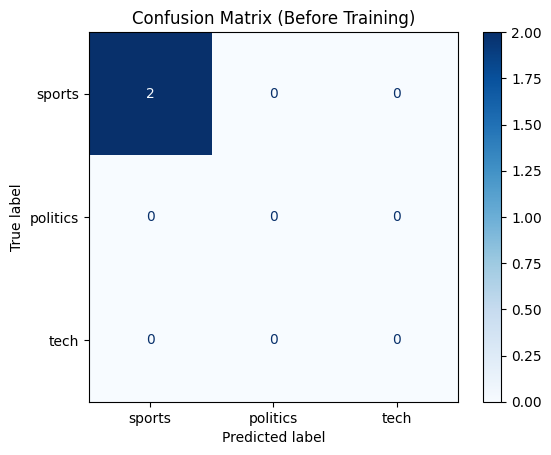

Accuracy: 1.0


In [11]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

label_names = ["sports", "politics", "tech"]

def extract_label_from_output(output_text):
    for label in label_names:
        if label in output_text.lower():
            return label
    return "unknown"

def evaluate_model(split="test"):
    model.eval()
    preds, targets = [], []

    for example in dataset[split]:
        prompt = example["prompt"]
        expected = example["response"]

        input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(model.device)
        with torch.no_grad():
            output = model.generate(input_ids, max_new_tokens=5)
        decoded = tokenizer.decode(output[0], skip_special_tokens=True)
        pred_label = extract_label_from_output(decoded)

        preds.append(pred_label)
        targets.append(expected)

    # Filter unknowns
    valid = [(p, t) for p, t in zip(preds, targets) if p in label_names]
    if not valid:
        print("⚠️ No valid predictions yet.")
        return

    y_pred, y_true = zip(*valid)
    cm = confusion_matrix(y_true, y_pred, labels=label_names)
    disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
    disp.plot(cmap="Blues")
    plt.title("Confusion Matrix (Before Training)")
    plt.show()

    print("Accuracy:", accuracy_score(y_true, y_pred))

evaluate_model()


In [15]:
import os
os.environ["WANDB_DISABLED"] = "true"  # ✅ Disable wandb logging

trainer.train()


/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss


TrainOutput(global_step=15, training_loss=0.25718453725179036, metrics={'train_runtime': 67.7241, 'train_samples_per_second': 0.443, 'train_steps_per_second': 0.221, 'total_flos': 164312792432640.0, 'train_loss': 0.25718453725179036, 'epoch': 5.0})

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


🔍 Evaluating AFTER fine-tuning...


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


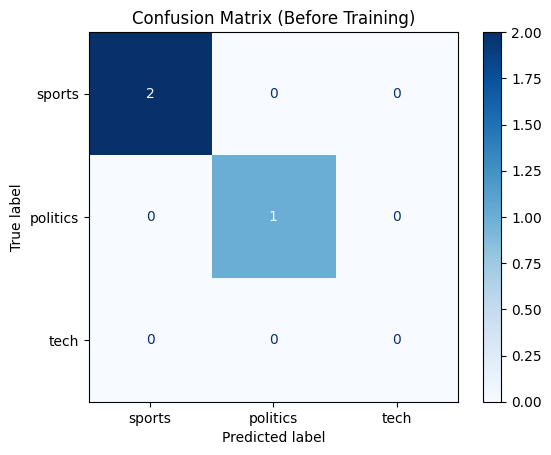

Accuracy: 1.0


In [16]:
print("🔍 Evaluating AFTER fine-tuning...")
evaluate_model()
